In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [130]:
df = pd.read_csv('data.csv', encoding='ISO-8859-1')
display(df.head(3))
print("shape:", df.shape)
display(df.describe())
df.info()
df.isnull().sum()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom


shape: (541909, 8)


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [131]:
print("distinct country:", df["Country"].nunique())
print(df["Country"].value_counts())

print("distinct stockcode:", df["StockCode"].nunique())
print(df["StockCode"].value_counts())

print("distinct description:", df["Description"].nunique())
print(df["Description"].value_counts())

print(df["StockCode"].value_counts(dropna=False)) # StockCode and Description are the Product code/name
print(df["Description"].value_counts(dropna=False))

distinct country: 38
Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA       

In [132]:
display(df.describe())

print("Num of negative Quantity: ", df[df["Quantity"] < 0].shape[0])
print("Num of negative or zero UnitPrice: ", df[df["UnitPrice"] <= 0].shape[0])


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


Num of negative Quantity:  10624
Num of negative or zero UnitPrice:  2517


In [133]:
region_lookup_table = {
    "United Kingdom": "UK&IE",
    "Germany": "Western Europe",
    "France": "Western Europe",
    "EIRE": "UK&IE",
    "Spain": "Southern Europe",
    "Netherlands": "Western Europe",
    "Belgium": "Western Europe",
    "Switzerland": "Western Europe",
    "Portugal": "Southern Europe",
    "Australia": "Oceania",
    "Norway": "Northern Europe",
    "Italy": "Southern Europe",
    "Channel Islands": "UK&IE",
    "Finland": "Northern Europe",
    "Cyprus": "Southern Europe",
    "Sweden": "Northern Europe",
    "Unspecified": "Unknown",
    "Austria": "Western Europe",
    "Denmark": "Northern Europe",
    "Japan": "East Asia",
    "Poland": "Eastern Europe",
    "Israel": "Middle East",
    "USA": "North America",
    "Hong Kong": "East Asia",
    "Singapore": "Southeast Asia",
    "Iceland": "Northern Europe",
    "Canada": "North America",
    "Greece": "Southern Europe",
    "Malta": "Southern Europe",
    "United Arab Emirates": "Middle East",
    "European Community": "Europe",
    "RSA": "Africa",
    "Lebanon": "Middle East",
    "Lithuania": "Eastern Europe",
    "Brazil": "South America",
    "Czech Republic": "Eastern Europe",
    "Bahrain": "Middle East",
    "Saudi Arabia": "Middle East"
}
region_lookup_df = pd.DataFrame(list(region_lookup_table.items()), columns=["country", "region"])

In [134]:
# display(df.iloc[0:3])
# df["LineItem"] = df.index
# display(df.loc[:, ["Quantity", "UnitPrice"]].head())
# df2 = df.set_index(df.index)
# display(df2.loc[0:3])

display(df.iloc[0:3])
df.index = pd.Index([f"L{i:06d}" for i in range(len(df))], name="line-item")
display(df.loc["L000005"])

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom


InvoiceNo                            536365
StockCode                             22752
Description    SET 7 BABUSHKA NESTING BOXES
Quantity                                  2
InvoiceDate                  12/1/2010 8:26
UnitPrice                              7.65
CustomerID                          17850.0
Country                      United Kingdom
Name: L000005, dtype: object

In [135]:
print("Cancellations:", df[df["InvoiceNo"].str.startswith("C")].shape[0])
print("Num of negative or zero Quantity: ", df[df["Quantity"] <= 0].shape[0])
print("Num of negative or zero UnitPrice: ", df[df["UnitPrice"] <= 0].shape[0]) # I think I did it previuosly, but I'll just follow instruction


Cancellations: 9288
Num of negative or zero Quantity:  10624
Num of negative or zero UnitPrice:  2517


In [136]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df["Revenue"] = df["Revenue"].round(3)
sorted_in_largest_bulk_orders = df.sort_values("Quantity", ascending=False)
print("Largest Bulk Orders: \n", sorted_in_largest_bulk_orders.head(1))
sorted_in_largest_returns = df.sort_values("Revenue", ascending=False)
print("Largest returns: \n", sorted_in_largest_returns.head(1))

Largest Bulk Orders: 
           InvoiceNo StockCode                  Description  Quantity  \
line-item                                                              
L540421      581483     23843  PAPER CRAFT , LITTLE BIRDIE     80995   

              InvoiceDate  UnitPrice  CustomerID         Country   Revenue  
line-item                                                                   
L540421    12/9/2011 9:15       2.08     16446.0  United Kingdom  168469.6  
Largest returns: 
           InvoiceNo StockCode                  Description  Quantity  \
line-item                                                              
L540421      581483     23843  PAPER CRAFT , LITTLE BIRDIE     80995   

              InvoiceDate  UnitPrice  CustomerID         Country   Revenue  
line-item                                                                   
L540421    12/9/2011 9:15       2.08     16446.0  United Kingdom  168469.6  


In [137]:
# Begin of Phoenix
data = df

In [138]:
# Phase C
# 3.6
data["Country"] = data["Country"].replace({ "EIRE": "Ireland", "RSA": "South Africa", "Unspecified": pd.NA })  # type: ignore
print("EIRE -> Ireland, RSA -> South Africa, Unspecified -> missing")
print(data["Country"].value_counts(dropna=False).head())

EIRE -> Ireland, RSA -> South Africa, Unspecified -> missing
Country
United Kingdom    495478
Germany             9495
France              8557
Ireland             8196
Spain               2533
Name: count, dtype: int64


In [139]:
# 3.7
COLUMN_MAP={
    "InvoiceNo": "invoice_no", "StockCode": "stock_code",
    "Description": "description", "Quantity": "quantity",
    "InvoiceDate": "invoice_date", "UnitPrice": "unit_price",
    "CustomerID": "customer_id", "Country": "country",
}
df.rename(columns=COLUMN_MAP, inplace=True)
print(df.columns)


Index(['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date',
       'unit_price', 'customer_id', 'country', 'Revenue'],
      dtype='str')


In [140]:
# 3.10
# Custom ID
print("Number of missing customer IDs:", data["customer_id"].isnull().sum())
data["customer_id"] = data["customer_id"].fillna(-1)
# Empty descriptions
# mask = data["description"].str.strip().eq("")
print("Number of empty descriptions:", data["description"].isnull().sum())
data["description"] = data["description"].fillna(pd.NA)


Number of missing customer IDs: 135080
Number of empty descriptions: 1454


In [141]:
# 3.11
# [TODO]?
# data.dropna(subset=["description"])

In [142]:
# 3.12
# is_cancelled bad_price bad_qty
is_cancelled = data["invoice_no"].astype(str).str.startswith("C")
bad_qty = data["quantity"] <= 0
bad_price = data["unit_price"] <= 0

print(f"Data size before dropping invalid rows: {len(data)}")
data = data.drop(index=data[is_cancelled | bad_price | bad_qty].index)
not_product = (~data["stock_code"].astype(str).str.match(r"^\d{5}"))
data = data.drop(index=data[not_product].index)
data = data.dropna(subset=["description"])
print(f"Data size after dropping invalid rows: {len(data)}")

Data size before dropping invalid rows: 541909
Data size after dropping invalid rows: 527725


In [143]:
# 3.13
duplicate_number = int(data.duplicated().sum())
data = data.drop_duplicates().reset_index(drop=True)
print("Exact duplicate rows removed:", duplicate_number)
print("Rows remaining:", len(data))

Exact duplicate rows removed: 5221
Rows remaining: 522504


In [144]:
# Phase D
# 3.18
data.rename(columns={"Revenue": "revenue"}, inplace=True)
# data.columns

data["description"] = data["description"].apply(lambda s: str(s).strip().title())
data["is_cancelled"] = data["invoice_no"].astype(str).str.startswith("C")

data.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue,is_cancelled
0,536365,85123A,White Hanging Heart T-Light Holder,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30,False
1,536365,71053,White Metal Lantern,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,False
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00,False
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,False
4,536365,84029E,Red Woolly Hottie White Heart.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,False


In [145]:
# 3.17
import time

s = time.time()
cleaned_desc_list = []
unique_data = data["description"].unique()
for des in unique_data:
    cleaned = str(des).strip().title()
    cleaned_desc_list.append(cleaned)
e = time.time()
print(f"for-loop: time cost in {e - s:.4f} seconds")

s = time.time()
cleaned_desc_list = [
    str(des).strip().title() for des in data["description"].unique()
]
e = time.time()
print(f"list comprehension: time cost in {e - s:.4f} seconds")

s = time.time()
data["description"] = data["description"].apply(lambda s: str(s).strip().title())
e = time.time()
print(f"apply: time cost in {e - s:.4f} seconds")

# In my timing test, approach `list comprehension` > `for-loop` > `apply`, in terms of speed.
# This might be reasonable because apply often still executes Python-level operations element by element.

for-loop: time cost in 0.1057 seconds
list comprehension: time cost in 0.0824 seconds
apply: time cost in 0.3873 seconds


In [146]:
# 3.14
rev_by_country = data.groupby("country")["revenue"].sum().sort_values(ascending=False)
print("Revenue by country:", rev_by_country.head(), sep="\n")

print(f"\n{'-' * 25}\n")

orders_per_customer = data[data["customer_id"] != -1].groupby("customer_id")["invoice_no"].nunique().sort_values(ascending=False)
print("Orders per customer:", orders_per_customer.head(), sep="\n")

Revenue by country:
country
United Kingdom    8724045.22
Netherlands        283889.34
Ireland            270850.86
Germany            205381.15
France             184493.00
Name: revenue, dtype: float64

-------------------------

Orders per customer:
customer_id
12748.0    206
14911.0    198
17841.0    124
13089.0     97
15311.0     91
Name: invoice_no, dtype: int64


In [147]:
# 3.16
by_country = data.groupby("country").agg(
    total_revenue=("revenue", "sum"),
    mean_line_value=("revenue", "mean"),
    transactions=("invoice_no", "nunique"),
).sort_values("total_revenue", ascending=False)
# by_country.head()

mask = data["customer_id"] != -1
by_customer = data[mask].groupby("customer_id").agg(
    total_revenue=("revenue", "sum"),
    mean_line_value=("revenue", "mean"),
    transactions=("invoice_no", "nunique"),
).sort_values("transactions", ascending=False)
by_customer.head()

,total_revenue,mean_line_value,transactions
customer_id,,,
12748.0,31650.78,7.198267,206
14911.0,136161.83,24.384282,198
17841.0,40495.99,5.281856,124
13089.0,58762.08,32.393649,97
15311.0,60632.75,25.626691,91


In [148]:
# 3.19
data["invoice_date"] = pd.to_datetime(data["invoice_date"])  # Also for 3.15

valid_customers = data[data["customer_id"] != -1]

def customer_summary(cs):
    return pd.Series({
        "total_spend":   cs["revenue"].sum(),
        "n_orders":      cs["invoice_no"].nunique(),
        "active_months": cs["invoice_date"].dt.to_period("M").nunique(),
    })

per_customer = valid_customers.groupby("customer_id").apply(customer_summary)
per_customer["n_orders"] = per_customer["n_orders"].astype(int)
per_customer["active_months"] = per_customer["active_months"].astype(int)
per_customer.sort_values("n_orders", ascending=False).head()


,total_spend,n_orders,active_months
customer_id,,,
12748.0,31650.78,206,13
14911.0,136161.83,198,13
17841.0,40495.99,124,13
13089.0,58762.08,97,13
15311.0,60632.75,91,13


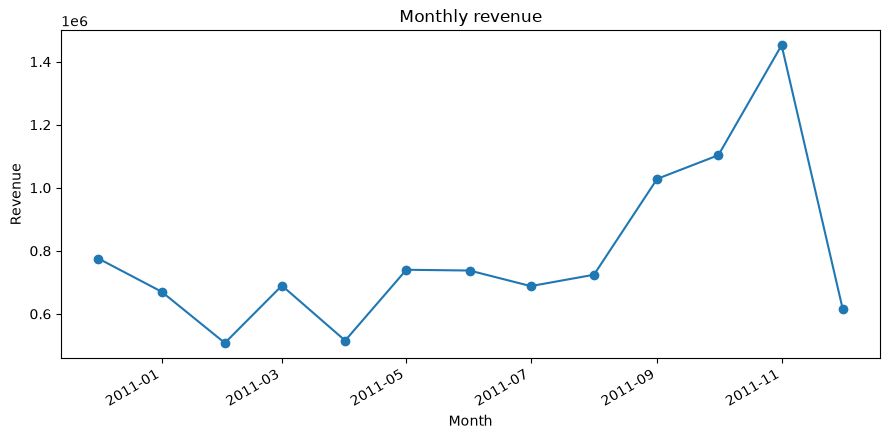

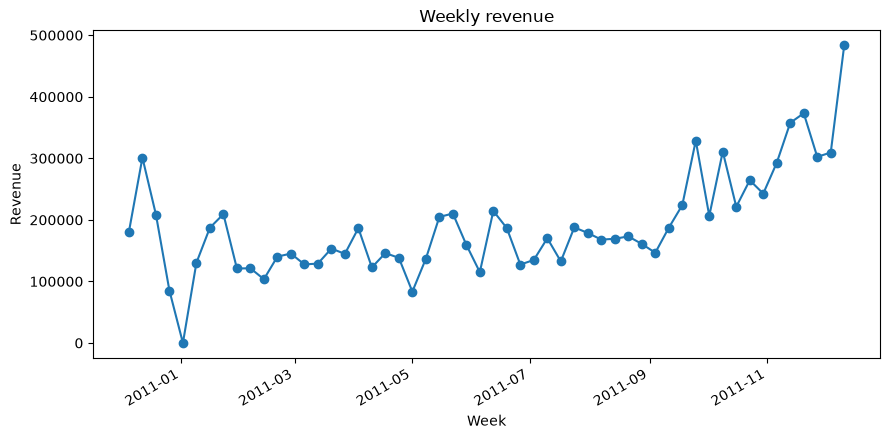

In [149]:
# 3.15
ts = data.set_index("invoice_date").sort_index()

# Monthly
monthly = ts["revenue"].resample("MS").sum()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(monthly.index, monthly.values, marker="o")
ax.set_title("Monthly revenue"); ax.set_xlabel("Month"); ax.set_ylabel("Revenue")
fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(r"monthly_revenue.png")

# Weekly
weekly = ts["revenue"].resample("W").sum()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(weekly.index, weekly.values, marker="o")
ax.set_title("Weekly revenue"); ax.set_xlabel("Week"); ax.set_ylabel("Revenue")
fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(r"weekly_revenue.png")
plt.show()

In [150]:
# END of Phoenix
df = data

In [151]:
first_half = df[df["invoice_date"].dt.month <= 6]
second_half = df[df["invoice_date"].dt.month > 6]
pd.concat([first_half, second_half])

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue,is_cancelled
40821,539993,22386,Jumbo Bag Pink Polkadot,10,2011-01-04 10:00:00,1.95,13313.0,United Kingdom,19.50,False
40822,539993,21499,Blue Polkadot Wrap,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom,10.50,False
40823,539993,21498,Red Retrospot Wrap,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom,10.50,False
40824,539993,22379,Recycling Bag Retrospot,5,2011-01-04 10:00:00,2.10,13313.0,United Kingdom,10.50,False
40825,539993,20718,Red Retrospot Shopper Bag,10,2011-01-04 10:00:00,1.25,13313.0,United Kingdom,12.50,False
...,...,...,...,...,...,...,...,...,...,...
522499,581587,22613,Pack Of 20 Spaceboy Napkins,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,False
522500,581587,22899,Children'S Apron Dolly Girl,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,False
522501,581587,23254,Childrens Cutlery Dolly Girl,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,False
522502,581587,23255,Childrens Cutlery Circus Parade,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,False


In [152]:
df_left = df.merge(region_lookup_df, on="country", how="left")
df_inner = df.merge(region_lookup_df, on="country", how="inner")

display(df_left.head())
display(df_inner.head())

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue,is_cancelled,region
0,536365,85123A,White Hanging Heart T-Light Holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,False,UK&IE
1,536365,71053,White Metal Lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,UK&IE
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,False,UK&IE
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,UK&IE
4,536365,84029E,Red Woolly Hottie White Heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,UK&IE


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue,is_cancelled,region
0,536365,85123A,White Hanging Heart T-Light Holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,False,UK&IE
1,536365,71053,White Metal Lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,UK&IE
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,False,UK&IE
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,UK&IE
4,536365,84029E,Red Woolly Hottie White Heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,UK&IE


In [153]:

# Save the cleaned data to a new CSV file
data.to_csv(r"cleaned_data.csv", index=False)